
Dateien in /Users/std_admin/Desktop/system/ETH/Bachelor Physics/ETH-Data-Analysis/Jupiter notebooks/ExamLibary:
  [0] Voltages.txt
-> Überspringe 1 Kopfzeile(n).
-> Erkannter Separator: ' '
-> Ausrichtung korrigiert: Daten transponiert (3x50000 -> 50000x3).

STATISTISCHE KENNZAHLEN PRO VARIABLE
Variable 1:
  Mittelwert: 20.0000 | Median: 20.0000 | Modus: 0.0000 | Std: 11.5474 | Var: 133.3413

Variable 2:
  Mittelwert: 0.9975 | Median: 1.0000 | Modus: 1.0500 | Std: 0.2998 | Var: 0.0899

Variable 3:
  Mittelwert: 1.0839 | Median: 1.0000 | Modus: 0.8800 | Std: 0.6116 | Var: 0.3740


Zeitbasis erkannt (Variable 1).

Erzeuge Korrelations-Plots...


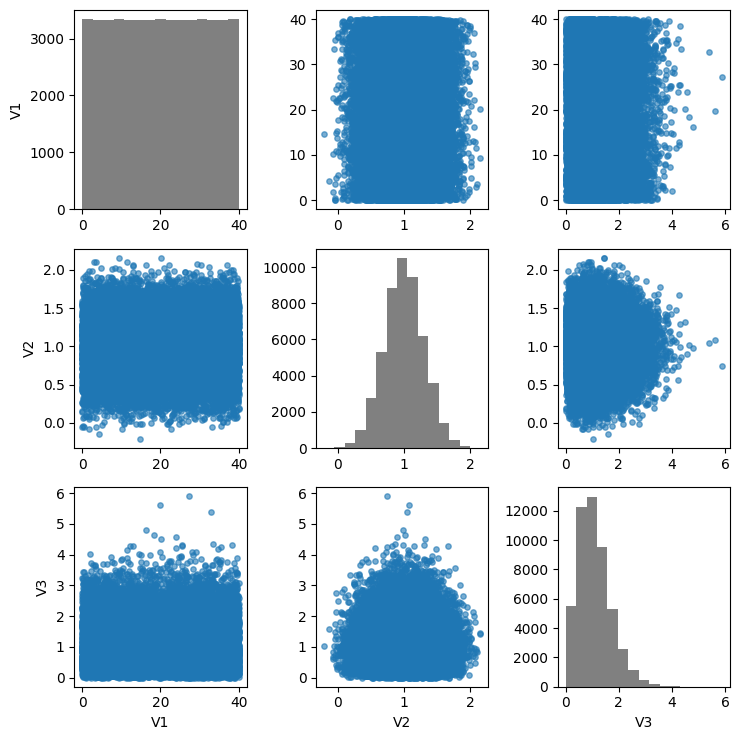

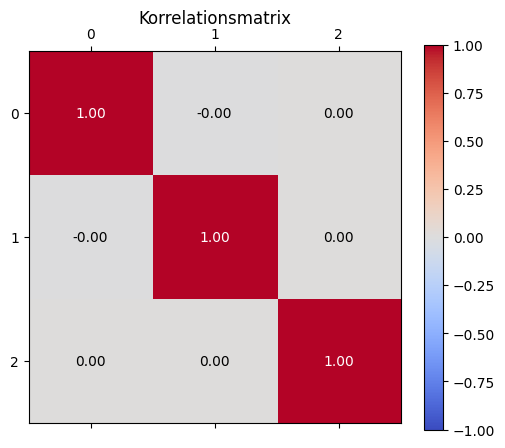

In [3]:
# FÜGE DIESEN BEFEHL GANZ OBEN IN DEINE JUPYTER ZELLE EIN:
# %matplotlib tk

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RangeSlider, Slider
from scipy.signal import find_peaks
import csv
import os

def detect_delimiter_and_load(filepath):
    """Liest die Datei, überspringt Kopfzeilen, erkennt den Separator und lädt die Daten."""
    with open(filepath, 'r', encoding='utf-8') as file:
        lines = file.readlines()
        
    data_start_idx = 0
    for i, line in enumerate(lines):
        clean_line = line.strip()
        if clean_line and (clean_line[0].isdigit() or clean_line[0] == '-'):
            data_start_idx = i
            break
            
    print(f"-> Überspringe {data_start_idx} Kopfzeile(n).")

    sample_text = "".join(lines[data_start_idx:data_start_idx+5])
    delimiter = ',' 
    
    try:
        sniffer = csv.Sniffer()
        dialect = sniffer.sniff(sample_text)
        delimiter = dialect.delimiter
        print(f"-> Erkannter Separator: '{delimiter}'")
    except csv.Error:
        if '\t' in lines[data_start_idx]: delimiter = '\t'
        elif ';' in lines[data_start_idx]: delimiter = ';'
        print(f"-> Sniffer unsicher. Manueller Fallback auf Separator: {repr(delimiter)}")

    data = np.genfromtxt(filepath, delimiter=delimiter, skip_header=data_start_idx, filling_values=np.nan)
    
    if data.ndim == 1:
        data = data.reshape(-1, 1)
    
    data = data[~np.isnan(data).all(axis=1)] 
    data = data[:, ~np.isnan(data).all(axis=0)] 
    return data

def adjust_orientation(data):
    """Prüft, ob die Daten vertikal oder horizontal vorliegen."""
    rows, cols = data.shape
    if rows < cols:
        print(f"-> Ausrichtung korrigiert: Daten transponiert ({rows}x{cols} -> {cols}x{rows}).")
        return data.T
    print(f"-> Ausrichtung beibehalten: {rows} Zeilen, {cols} Spalten.")
    return data

def numpy_mode(array):
    values, counts = np.unique(array, return_counts=True)
    return values[np.argmax(counts)]

def calculate_statistics(data):
    """Berechnet statistische Kennzahlen und gibt sie in der Konsole aus."""
    num_vars = data.shape[1]
    print("\n" + "="*40)
    print("STATISTISCHE KENNZAHLEN PRO VARIABLE")
    print("="*40)
    
    for i in range(num_vars):
        col_data = data[:, i]
        col_data = col_data[~np.isnan(col_data)] 
        if len(col_data) == 0: continue
            
        mean = np.mean(col_data)
        median = np.median(col_data)
        mode = numpy_mode(col_data)
        std = np.std(col_data, ddof=1) if len(col_data) > 1 else 0
        variance = np.var(col_data, ddof=1) if len(col_data) > 1 else 0
        
        print(f"Variable {i+1}:\n  Mittelwert: {mean:.4f} | Median: {median:.4f} | Modus: {mode:.4f} | Std: {std:.4f} | Var: {variance:.4f}\n")

def detect_time_columns(data, tolerance=1e-5):
    """Sucht nach Spalten, die eine gleichmäßige Zeitbasis darstellen könnten."""
    time_cols = []
    for i in range(data.shape[1]):
        col = data[:, i]
        col_clean = col[~np.isnan(col)]
        if len(col_clean) < 2: continue
            
        diffs = np.diff(col_clean)
        mean_diff = np.mean(diffs)
        
        if mean_diff <= 0: continue
            
        if np.allclose(diffs, mean_diff, rtol=tolerance, atol=tolerance):
            time_cols.append(i)
    return time_cols

def interactive_time_analysis(data, time_idx):
    """Integriertes Dashboard: Interaktiver Filter, Moving Average, Peaks, PSD und Autokovarianz."""
    time_col = data[:, time_idx]
    
    valid_rows = ~np.isnan(time_col)
    time_col = time_col[valid_rows]
    data_clean = data[valid_rows, :]
    
    dt = np.mean(np.diff(time_col)) 
    fs = 1.0 / dt                   
    n = len(time_col)
    freqs = np.fft.rfftfreq(n, d=dt)
    
    filtered_signals = {}
    
    for i in range(data_clean.shape[1]):
        if i == time_idx: continue 
            
        signal = data_clean[:, i]
        if np.isnan(signal).any():
            signal = np.nan_to_num(signal, nan=np.nanmean(signal))
            
        signal_mean = np.mean(signal)
        signal_detrended = signal #- signal_mean
        
        # FFT & Basis-Analyse
        fft_orig = np.fft.rfft(signal_detrended)
        fft_mag = np.abs(fft_orig)
        psd_vals = (fft_mag ** 2) / (fs * n)
        autocov = np.correlate(signal_detrended, signal_detrended, mode='full')
        autocov = autocov[n - 1:] / n 
        lags = np.arange(len(autocov)) * dt
        
        # Peak Erkennung
        peaks_idx, _ = find_peaks(fft_mag, prominence=np.max(fft_mag)*0.05)
        peak_freqs = freqs[peaks_idx]
        peak_mags = fft_mag[peaks_idx]
        
        # Dashboard Plotting
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        plt.subplots_adjust(bottom=0.25, hspace=0.4, wspace=0.2)
        
        ax_time, ax_freq = axes[0, 0], axes[0, 1]
        ax_psd, ax_autocov = axes[1, 0], axes[1, 1]
        
        line_orig, = ax_time.plot(time_col, signal, color='lightgray', label='Original')
        line_filt, = ax_time.plot(time_col, signal, color='blue', label='Gefiltert', alpha=0.8)
        ax_time.set_title(f"Zeitsignal - V{i+1}")
        ax_time.legend(loc="upper right")
        
        line_fft, = ax_freq.plot(freqs, fft_mag, color='black')
        ax_freq.scatter(peak_freqs, peak_mags, color='red', s=50, label='Peaks')
        ax_freq.set_title("Amplitudenspektrum & Filter")
        
        ax_psd.semilogy(freqs, psd_vals, color='red')
        ax_psd.set_title("PSD (Leistungsdichte)")
        
        ax_autocov.plot(lags, autocov, color='green')
        ax_autocov.set_title("Autokovarianz")
        
        # Slider
        ax_slider_freq = plt.axes([0.15, 0.1, 0.7, 0.03])
        slider_freq = RangeSlider(ax_slider_freq, 'FFT Band [Hz]', freqs[0], freqs[-1], valinit=(freqs[0], freqs[-1]))
        
        ax_slider_ma = plt.axes([0.15, 0.05, 0.7, 0.03])
        slider_ma = Slider(ax_slider_ma, 'MA Interval k', 0, (n-1)//2, valinit=0, valstep=1)
        
        current_filtered = [signal.copy()]
        
        def update(val=None):
            f_min, f_max = slider_freq.val
            k = int(slider_ma.val)
            
            fft_f = fft_orig.copy()
            fft_f[(freqs < f_min) | (freqs > f_max)] = 0
            sig_fft = np.fft.irfft(fft_f, n=n) #+ signal_mean
            
            if k > 0:
                win = np.ones(2*k+1) / (2*k+1)
                ma = np.convolve(sig_fft, win, mode='valid')
                sig_final = sig_fft.copy()
                sig_final[k:-k] = ma
            else: sig_final = sig_fft
            
            line_filt.set_ydata(sig_final)
            line_fft.set_ydata(np.abs(fft_f))
            current_filtered[0] = sig_final
            fig.canvas.draw_idle()
            
        slider_freq.on_changed(update); slider_ma.on_changed(update)
        plt.show()
        filtered_signals[f"Var_{i+1}"] = current_filtered[0]
        
    return filtered_signals

def plot_scatter_matrix(data):
    num_vars = data.shape[1]
    if num_vars <= 1: return
    fig, axes = plt.subplots(num_vars, num_vars, figsize=(2.5 * num_vars, 2.5 * num_vars))
    for i in range(num_vars):
        for j in range(num_vars):
            ax = axes[i, j] if num_vars > 1 else axes
            valid_i, valid_j = ~np.isnan(data[:, i]), ~np.isnan(data[:, j])
            if i == j: ax.hist(data[:, i][valid_i], bins=15, color='gray')
            else:
                valid_both = valid_i & valid_j
                ax.scatter(data[:, j][valid_both], data[:, i][valid_both], alpha=0.6, s=15)
            if i == num_vars - 1: ax.set_xlabel(f'V{j+1}')
            if j == 0: ax.set_ylabel(f'V{i+1}')
    plt.tight_layout(); plt.show()

def plot_correlation_matrix(data):
    if data.shape[1] <= 1: return
    clean_data = data[~np.isnan(data).any(axis=1)]
    corr = np.corrcoef(clean_data, rowvar=False)
    fig, ax = plt.subplots(figsize=(6, 5))
    cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    fig.colorbar(cax)
    for i in range(data.shape[1]):
        for j in range(data.shape[1]):
            ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', 
                    color='black' if abs(corr[i,j]) < 0.5 else 'white')
    plt.title('Korrelationsmatrix', pad=20); plt.show()

def plot_histogram(data):
    """Plottet ein einfaches Histogramm, wenn nur eine Variable vorhanden ist."""
    clean_data = data[~np.isnan(data)]
    
    plt.figure(figsize=(8, 5))
    plt.hist(clean_data, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
    plt.title('Verteilung der Variable 1 (Histogramm)')
    plt.xlabel('Werte')
    plt.ylabel('Häufigkeit')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

def pick_file():
    cwd = os.getcwd()
    files = sorted([f for f in os.listdir(cwd) if f.endswith(('.txt', '.csv'))])
    if not files:
        print(f"Keine .txt/.csv Dateien in {cwd} gefunden.")
        return None
    print(f"\nDateien in {cwd}:")
    for i, f in enumerate(files):
        print(f"  [{i}] {f}")
    choice = input("\nNummer eingeben: ").strip()
    try:
        return os.path.join(cwd, files[int(choice)])
    except (ValueError, IndexError):
        print("Ungültige Eingabe."); return None

def main(filepath=None):
    if filepath is None:
        filepath = pick_file()
    
    if not filepath:
        print("Abbruch."); return None, None

    # Laden & Statistik
    data = adjust_orientation(detect_delimiter_and_load(filepath))
    calculate_statistics(data)
    
    # Zeitreihen-Analyse
    time_cols = detect_time_columns(data)
    filtered_res = {}
    if time_cols:
        for idx in time_cols:
            print(f"\nZeitbasis erkannt (Variable {idx+1}).")
            choice = input("Dashboard starten? (j/n): ").strip().lower()
            if choice in ['j', 'ja', 'y']:
                filtered_res = interactive_time_analysis(data, idx)
                break
    
    # Korrelationen ODER Histogramm
    if data.shape[1] > 1:
        print("\nErzeuge Korrelations-Plots...")
        plot_scatter_matrix(data)
        plot_correlation_matrix(data)
    else:
        print("\nDatensatz besteht nur aus einer Variable. Erzeuge Histogramm...")
        plot_histogram(data)
    
    return data, filtered_res

data, filtered = main()